# Download and prepare data 

1. UAVSAR SLCs -> coherence rasters
    1. Download from JPL 
    2. Geolocate, calculate coherence for each image pair 
    3. Reproject and downsample to 30m 
    4. Get outline shapefile for each scene
2. Get DEM 
    1. Download using 3dep API and clip to scene extents
    2. Reproject and downsample to 30m
    3. Calculate slope, aspect, convexity
3. Calculate incidence angle
    1. Use uavsar_pytools to calculate incidence angle
4. Get other input data 




In [57]:
import numpy as np 
import os
import sys
from osgeo import gdal, ogr, osr
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()

from uavsar_pytools import UavsarCollection

### UAVSAR Data

- Where to find it? 
- How to download it? 
Users will be on their own for this. SLCs have to be downloaded from [JPL's UAVSAR site](https://uavsar.jpl.nasa.gov/cgi-bin/data.pl) and I can't find a good way to automate it. 
- Processing steps: 
    - Geolocation
    - Coherence calculation
    - Reprojection and downsampling
    - Temporal model fit and 12-day prediction

In [19]:
slc_dir = '../data/uavsar/slc/'

def tif_to_shapefile(tif_path, out_shapefile):
    """
    Convert a GeoTIFF to a shapefile containing a single polygon
    that outlines all valid (non-nodata) pixels.
    """
    ds = gdal.Open(tif_path)
    if ds is None:
        raise RuntimeError(f"Failed to open: {tif_path}")

    band = ds.GetRasterBand(1)
    if band is None:
        raise RuntimeError(f"No raster band in: {tif_path}")

    arr = band.ReadAsArray()
    nodata = band.GetNoDataValue()

    # robust valid-mask (handles NaN and nodata)
    if nodata is None:
        mask = np.isfinite(arr)
    else:
        # use isclose for float nodata, and also require finite values
        mask = np.isfinite(arr) & (~np.isclose(arr, nodata))

    print("total:", arr.size, "valid:", int(mask.sum()),
      "nan:", int(np.isnan(arr).sum()),
      "==nodata:", int(np.isclose(arr, nodata).sum()) if nodata is not None else 0)

    if not mask.any():
        raise RuntimeError("No valid data found in raster.")

    # create in-memory raster of the mask
    mem_drv = gdal.GetDriverByName("MEM")
    mem = mem_drv.Create("", ds.RasterXSize, ds.RasterYSize, 1, gdal.GDT_Byte)
    mem.SetGeoTransform(ds.GetGeoTransform())
    mem.SetProjection(ds.GetProjection())
    mem_band = mem.GetRasterBand(1)
    mem_band.WriteArray(mask.astype(np.uint8))
    mem_band.FlushCache()

    # polygonize into an in-memory vector layer
    ogr_drv = ogr.GetDriverByName("Memory")
    mem_ds = ogr_drv.CreateDataSource("mem")
    srs = None
    wkt = ds.GetProjection()
    if wkt:
        srs = osr.SpatialReference()
        srs.ImportFromWkt(wkt)
    layer = mem_ds.CreateLayer("mask", srs=srs, geom_type=ogr.wkbPolygon)
    fld = ogr.FieldDefn("value", ogr.OFTInteger)
    layer.CreateField(fld)
    gdal.Polygonize(mem.GetRasterBand(1), None, layer, 0, [], callback=None)

    # union polygons where value == 1
    layer.ResetReading()
    geom_union = None
    feat = layer.GetNextFeature()
    while feat:
        if feat.GetField("value") == 1:
            g = feat.GetGeometryRef()
            if g is not None:
                g_clone = g.Clone()
                if geom_union is None:
                    geom_union = g_clone
                else:
                    geom_union = geom_union.Union(g_clone)
        feat = layer.GetNextFeature()

    if geom_union is None:
        raise RuntimeError("No polygons created from mask.")

    # ensure MultiPolygon
    if geom_union.GetGeometryType() == ogr.wkbPolygon:
        multi = ogr.Geometry(ogr.wkbMultiPolygon)
        multi.AddGeometry(geom_union)
        geom_union = multi

    # write output shapefile (overwrite if exists)
    shp_drv = ogr.GetDriverByName("ESRI Shapefile")
    if os.path.exists(out_shapefile):
        shp_drv.DeleteDataSource(out_shapefile)
    out_ds = shp_drv.CreateDataSource(out_shapefile)
    out_layer = out_ds.CreateLayer("outline", srs=srs, geom_type=ogr.wkbMultiPolygon)
    id_fd = ogr.FieldDefn("id", ogr.OFTInteger)
    out_layer.CreateField(id_fd)

    feat_def = out_layer.GetLayerDefn()
    out_feat = ogr.Feature(feat_def)
    out_feat.SetGeometry(geom_union)
    out_feat.SetField("id", 1)
    out_layer.CreateFeature(out_feat)

    out_ds.Destroy()
    mem_ds.Destroy()
    mem = None
    ds = None

    print(f"Created outline shapefile: {out_shapefile}")

In [20]:
tif_to_shapefile("../data/lowman_05208_coherence_20200131_20200213.tif",
                 "../data/lowman_05208.shp")

total: 40798368 valid: 18674692 nan: 22123676 ==nodata: 0
Created outline shapefile: ../data/lowman_05208.shp


In [ ]:
# tif overview function 
from osgeo import gdal
import numpy as np

def print_tif_stats(tif_path):
    ds = gdal.Open(tif_path)
    if ds is None:
        print("Failed to open:", tif_path); return
    band = ds.GetRasterBand(1)
    arr = band.ReadAsArray().astype(float)
    nodata = band.GetNoDataValue()

    total = arr.size
    nan_count = np.isnan(arr).sum()
    zero_count = np.count_nonzero(arr == 0)
    nodata_count = 0 if nodata is None else np.count_nonzero(arr == nodata)
    valid_mask = ~np.isnan(arr)
    if nodata is not None:
        valid_mask &= (arr != nodata)
    valid_count = valid_mask.sum()

    print("file:", tif_path)
    print("size (cols, rows):", ds.RasterXSize, ds.RasterYSize)
    print("projection WKT (truncated):", (ds.GetProjection() or "")[:200])
    print("geotransform:", ds.GetGeoTransform())
    print("dtype:", arr.dtype, "nodata:", nodata)
    print("total pixels:", total)
    print("valid pixels (not nan and not nodata):", valid_count, f"({valid_count/total:.2%})")
    print("nan count:", int(nan_count), f"({nan_count/total:.2%})")
    print("zero count:", int(zero_count), f"({zero_count/total:.2%})")
    if nodata is not None:
        print("nodata count:", int(nodata_count), f"({nodata_count/total:.2%})")

    # min/max of valid pixels
    if valid_count:
        vals = arr[valid_mask]
        print("valid min/max:", float(np.nanmin(vals)), "/", float(np.nanmax(vals)))
    else:
        print("no valid pixels found")

# Example:
print_tif_stats("../data/lowman_05208_coherence_20200131_20200213.tif")

file: ../data/lowman_05208_coherence_20200131_20200213.tif
size (cols, rows): 4896 8333
projection WKT (truncated): GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.017453292519
geotransform: (-115.92393493652344, 0.00011444091796875, 0.0, 44.19214630126953, 0.0, -4.57763671875e-05)
dtype: float64 nodata: nan
total pixels: 40798368
valid pixels (not nan and not nodata): 18674692 (45.77%)
nan count: 22123676 (54.23%)
zero count: 345409 (0.85%)
nodata count: 0 (0.00%)
valid min/max: 0.0 / 1.0000003576278687


In [ ]:
# geolocate 


{
  "geometry": {
    "coordinates": [
      [
        [
          -116.368747,
          43.778382
        ],
        [
          -116.211674,
          43.627851
        ],
        [
          -114.989828,
          44.302195
        ],
        [
          -115.13245,
          44.439317
        ],
        [
          -116.368747,
          43.778382
        ]
      ]
    ],
    "type": "Polygon"
  },
  "properties": {
    "beamModeType": "RPI",
    "browse": [
      "https://datapool.asf.alaska.edu/BROWSE/UA/lowman_23205_21019-018_21021-006_0006d_s01_L090HH_01.cor.png",
      "https://datapool.asf.alaska.edu/BROWSE/UA/lowman_23205_21019-018_21021-006_0006d_s01_L090HH_01.hgt.png",
      "https://datapool.asf.alaska.edu/BROWSE/UA/lowman_23205_21019-018_21021-006_0006d_s01_L090HV_01.cor.png",
      "https://datapool.asf.alaska.edu/BROWSE/UA/lowman_23205_21019-018_21021-006_0006d_s01_L090HV_01.hgt.png",
      "https://datapool.asf.alaska.edu/BROWSE/UA/lowman_23205_21019-018_21021-006_00

### NLCD



<Axes: >

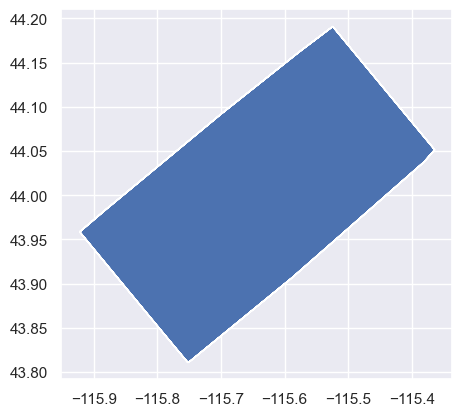

In [106]:
# check shapefile shape. i'll get kmls from HP hopefully. 
import pygeohydro as gh
import geopandas as gpd

outline = gpd.read_file('../data/lowman_05208.shp')
outline.plot()
# print(g)


In [61]:
forest_cover = gh.nlcd_bygeom(geometry=g)
print(forest_cover)
#plot canopy and cover
# fig, axes = plt.subplots(1, 2, figsize=(8, 4))
# forest_cover[0]['canopy_2021'].plot(ax=axes[0])
# axes[0].set_title('Canopy 2021')
# forest_cover[0]['cover_2021'].plot(ax=axes[1])
# axes[1].set_title('Cover 2021')
# fig.tight_layout()
# plt.show()

/Users/JULIALOBER/miniforge3/envs/coherence/lib/python3.13/site-packages/pygeoutils/pygeoutils.py:300: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  ds = xr.merge(


{0: <xarray.Dataset> Size: 21MB
Dimensions:          (x: 1497, y: 1408)
Coordinates:
  * x                (x) float64 12kB -115.9 -115.9 -115.9 ... -115.4 -115.4
  * y                (y) float64 11kB 44.19 44.19 44.19 ... 43.81 43.81 43.81
    spatial_ref      int64 8B 0
Data variables:
    impervious_2021  (y, x) float32 8MB nan nan nan nan nan ... nan nan nan nan
    cover_2021       (y, x) uint8 2MB 127 127 127 127 127 ... 127 127 127 127
    canopy_2021      (y, x) float32 8MB nan nan nan nan nan ... nan nan nan nan
    descriptor_2021  (y, x) uint8 2MB 127 127 127 127 127 ... 127 127 127 127
Attributes:
    TIFFTAG_XRESOLUTION:     1
    TIFFTAG_YRESOLUTION:     1
    TIFFTAG_RESOLUTIONUNIT:  1 (unitless)
    AREA_OR_POINT:           Area
    _FillValue:              255
    scale_factor:            1.0
    add_offset:              0.0}


In [93]:
# plot forest cover
type(forest_cover)
print(forest_cover[0]['cover_2021'])

# reproject forest cover to UTM zone 11N and 30 m resolution
fc_reproj = {}
fc_reproj['canopy_2021'] = forest_cover[0]['canopy_2021'].rio.reproject("EPSG:26911", resolution=30)
fc_reproj['cover_2021'] = forest_cover[0]['cover_2021'].rio.reproject("EPSG:26911", resolution=30)

# replace 127 with nan in the land cover data
fc_reproj['cover_2021'] = fc_reproj['cover_2021'].where(fc_reproj['cover_2021'] != 127, np.nan)


<xarray.DataArray 'cover_2021' (y: 1408, x: 1497)> Size: 2MB
array([[127, 127, 127, ..., 127, 127, 127],
       [127, 127, 127, ..., 127, 127, 127],
       [127, 127, 127, ..., 127, 127, 127],
       ...,
       [127, 127, 127, ..., 127, 127, 127],
       [127, 127, 127, ..., 127, 127, 127],
       [127, 127, 127, ..., 127, 127, 127]],
      shape=(1408, 1497), dtype=uint8)
Coordinates:
  * y            (y) float64 11kB 44.19 44.19 44.19 44.19 ... 43.81 43.81 43.81
  * x            (x) float64 12kB -115.9 -115.9 -115.9 ... -115.4 -115.4 -115.4
    spatial_ref  int64 8B 0
Attributes:
    TIFFTAG_XRESOLUTION:     1
    TIFFTAG_YRESOLUTION:     1
    TIFFTAG_RESOLUTIONUNIT:  1 (unitless)
    AREA_OR_POINT:           Area
    scale_factor:            1.0
    add_offset:              0.0
    _FillValue:              127
    crs:                     EPSG:4326
    nodatavals:              (127,)
    units:                   classes


{11: '#466b9f', 12: '#d1def8', 21: '#dec5c5', 22: '#d99282', 23: '#eb0000', 24: '#ab0000', 31: '#b3ac9f', 41: '#68ab5f', 42: '#1c5f2c', 43: '#b5c58f', 52: '#ccb879', 71: '#dfdfc2', 81: '#dcd939', 82: '#ab6c28', 90: '#b8d9eb', 95: '#6c9fb8'}


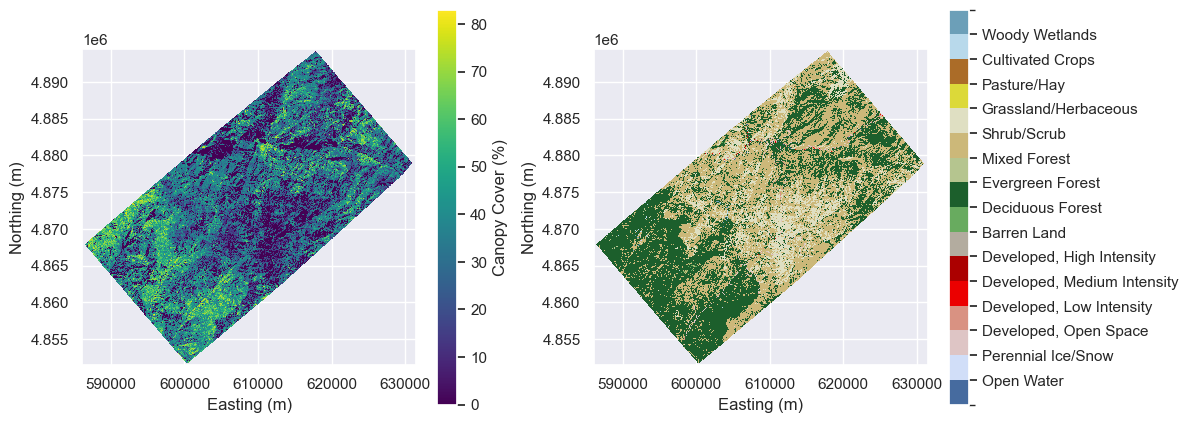

In [105]:

import matplotlib.colors as mcolors
from matplotlib.colors import ListedColormap

def get_landcover_cmap() : 
    # from https://colab.research.google.com/github/gee-community/geeViz/blob/master/examples/Annual_NLCD_Viewer_Notebook.ipynb#scrollTo=a588e083
    land_cover_vis = {'LC_class_values': [11, 12, 21, 22, 23, 24, 31, 41, 42, 43, 52, 71, 81, 82, 90, 95],
    'LC_class_palette' : [
    '466b9f', 'd1def8', 'dec5c5', 'd99282', 'eb0000', 'ab0000',
    'b3ac9f', '68ab5f', '1c5f2c', 'b5c58f', 'ccb879', 'dfdfc2', 
    'dcd939', 'ab6c28', 'b8d9eb', '6c9fb8'
    ],
    'LC_class_names' : [
    "Open Water", "Perennial Ice/Snow", "Developed, Open Space", "Developed, Low Intensity", 
    "Developed, Medium Intensity", "Developed, High Intensity", "Barren Land", 
    "Deciduous Forest", "Evergreen Forest", "Mixed Forest", "Shrub/Scrub", 
    "Grassland/Herbaceous", "Pasture/Hay", "Cultivated Crops", "Woody Wetlands", 
    "Emergent Herbaceous Wetlands"
    ]
    }
    col_dict = {land_cover_vis['LC_class_values'][i]: '#' + land_cover_vis['LC_class_palette'][i] for i in range(len(land_cover_vis['LC_class_values']))}
    print(col_dict)
    # col_dict = {
    #     1:"tomato",
    #     2:"plum",
    #     7:"lightgreen",
    #     11:"green",
    #     15:"maroon",
    #     16:"aqua",
    #     17:"navy",
    #     19:"goldenrod",
    #     22:"white",
    # }
    # labels = np.array([
    #     "Urban",
    #     "I Cropland",
    #     "Grassland",
    #     "B Deciduous",
    #     "Mixed Forest",
    #     "Water Bodies",
    #     "H Wetland", 
    #     "Barren",
    #     "Tundra",
    # ])
    ncolors = len(col_dict.keys())
    cm = ListedColormap([col_dict[x] for x in col_dict.keys()])
    np.random.seed(2112)
    lu_index = np.zeros((ncolors, ncolors))
    for nn,k in enumerate(col_dict.keys()):
        lu_index[nn, :] = k

    bounds = np.array([k for k in col_dict.keys()])
    bounds = bounds[:-1] + np.diff(bounds) / 2
    bounds = np.concatenate((np.array([0]), bounds, np.array([97])))
    norm = mcolors.BoundaryNorm(bounds, ncolors)
    return cm, norm, bounds

cover_cmap, cover_norm, cover_bounds = get_landcover_cmap()

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

img1 = fc_reproj['canopy_2021'].plot(ax=axes[0], add_colorbar=False)
axes[0].set_title('')
axes[0].set_aspect('equal')
axes[0].set_xlabel('Easting (m)')
axes[0].set_ylabel('Northing (m)')
axes[0].grid(True)
fig.colorbar(img1, ax=axes[0], shrink=0.7, label='Canopy Cover (%)')

# set a colorbar for the NLCD land cover types 
# cmap = land_cover_vis['LC_class_palette']
cover_class_names = [
    "Open Water", "Perennial Ice/Snow", "Developed, Open Space", "Developed, Low Intensity", 
    "Developed, Medium Intensity", "Developed, High Intensity", "Barren Land", 
    "Deciduous Forest", "Evergreen Forest", "Mixed Forest", "Shrub/Scrub", 
    "Grassland/Herbaceous", "Pasture/Hay", "Cultivated Crops", "Woody Wetlands", 
    "Emergent Herbaceous Wetlands"
    ]
img2 =fc_reproj['cover_2021'].plot(ax=axes[1], cmap=cover_cmap, norm=cover_norm, levels=cover_bounds, add_colorbar=False)
axes[1].set_title('')
axes[1].set_aspect('equal')
axes[1].set_xlabel('Easting (m)')
axes[1].set_ylabel('Northing (m)')
axes[1].grid(True)
cbar = fig.colorbar(img2, ax=axes[1], shrink=0.7)
cbar.set_ticks(cover_bounds[1:-1], labels = cover_class_names[:-1]) 
# cbar.tick_params(size=0)  # remove ticks



fig.tight_layout()
plt.show()

### DEM 

Use the 3DEP API to get a dem. 

In [ ]:
import py3dep 

slc_bounds 